In [ ]:
AULA01 - Otimização
Aluno: Neivan Júnior Alves Costa
GitHub: neivanjr-costa
Linguagem: Julia

### Import all packages need in the cell below

In [ ]:
using Plots
using JuMP
using Ipopt
using HiGHS
using LinearAlgebra

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

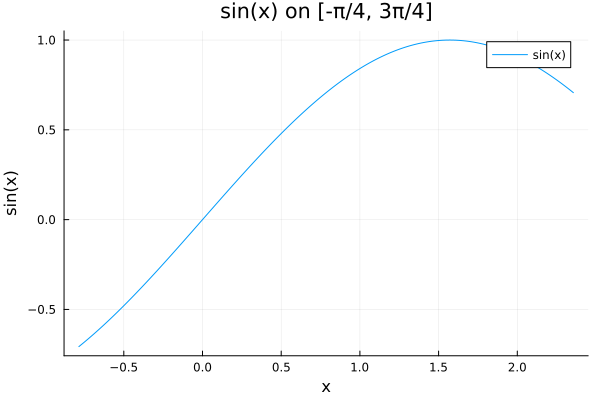

In [26]:
x = range(-pi/4, 3pi/4, length=400)
y = sin.(x)

plot(
    x, y,
    xlabel = "x",
    ylabel = "sin(x)",
    label = "sin(x)",
    title = "sin(x) on [-π/4, 3π/4]",
    legend = :topright
)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

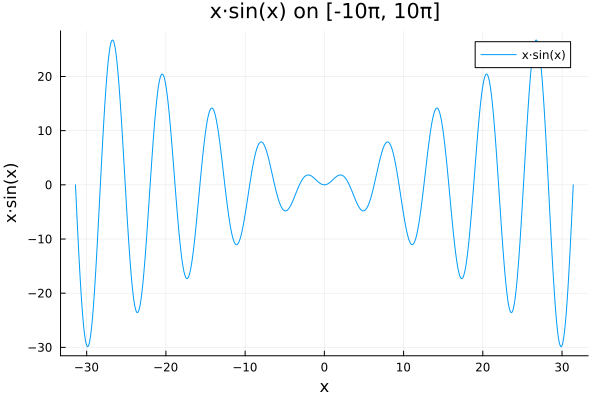

In [28]:
x = range(-10pi, 10pi, length=2000)
y = x .* sin.(x)

plot(
    x, y,
    xlabel = "x",
    ylabel = "x·sin(x)",
    label = "x·sin(x)",
    title = "x·sin(x) on [-10π, 10π]",
    legend = :topright
)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [30]:
N = 10.0
c1 = 2.0
c2 = 0.5

model_cyl = Model(Ipopt.Optimizer)
set_silent(model_cyl)

@variable(model_cyl, r >= 0.0)
@variable(model_cyl, h >= 0.0)

@NLexpression(model_cyl, V, pi * r^2 * h)
@NLobjective(
    model_cyl, Max,
    N * pi * r^2 * h - c1 * pi * r^2 - c2 * V * (pi * r^2 + 2pi * r * h)
)

set_start_value(r, 0.8)
set_start_value(h, 1.7)

optimize!(model_cyl)

r_opt = value(r)
h_opt = value(h)
V_opt = pi * r_opt^2 * h_opt
profit_opt = objective_value(model_cyl)

println("Cylinder problem")
println("r*      = ", r_opt)
println("h*      = ", h_opt)
println("V*      = ", V_opt)
println("profit* = ", profit_opt)

Cylinder problem
r*      = 0.8255542432640973
h*      = 1.7214671119189975
V*      = 3.6858684472078607
profit* = 12.174129240944932


# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [32]:
h = 2.0
w = 3.0

model_awning = Model(Ipopt.Optimizer)
set_silent(model_awning)

@variable(model_awning, x >= 1e-6)
@variable(model_awning, y >= 0.0)

@NLobjective(model_awning, Min, sqrt(x^2 + y^2))
@NLconstraint(model_awning, y - w * y / x >= h)

set_start_value(x, 5.0)
set_start_value(y, 4.0)

optimize!(model_awning)

x_opt = value(x)
y_opt = value(y)
z_opt = objective_value(model_awning)

println("Awning problem")
println("x* = ", x_opt)
println("y* = ", y_opt)
println("minimum awning length = ", z_opt)

Awning problem
x* = 5.289428478583723
y* = 4.620741382379412
minimum awning length = 7.0234823665248935


# Problem Statement

Solve the Packing Problem

In [34]:
item_sizes = [4, 8, 1, 4, 2, 1, 10]
bin_capacity = 10

n_items = length(item_sizes)
max_bins = n_items

model_pack = Model(HiGHS.Optimizer)
set_silent(model_pack)

@variable(model_pack, x[1:n_items, 1:max_bins], Bin)   # item i assigned to bin j
@variable(model_pack, y[1:max_bins], Bin)             # bin j used

@objective(model_pack, Min, sum(y[j] for j in 1:max_bins))

@constraint(model_pack, [i in 1:n_items], sum(x[i, j] for j in 1:max_bins) == 1)
@constraint(model_pack, [j in 1:max_bins],
    sum(item_sizes[i] * x[i, j] for i in 1:n_items) <= bin_capacity * y[j]
)

optimize!(model_pack)

used_bins = Int(round(objective_value(model_pack)))
println("Packing problem (generic model)")
println("Minimum number of bins = ", used_bins)

for j in 1:max_bins
    if value(y[j]) > 0.5
        packed = [i for i in 1:n_items if value(x[i, j]) > 0.5]
        println("Bin ", j, ": items ", packed, " -> sizes ", item_sizes[packed],
                ", total = ", sum(item_sizes[packed]))
    end
end

Packing problem (generic model)
Minimum number of bins = 3
Bin 1: items [1, 4, 5] -> sizes [4, 4, 2], total = 10
Bin 3: items [7] -> sizes [10], total = 10
Bin 4: items [2, 3, 6] -> sizes [8, 1, 1], total = 10


# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

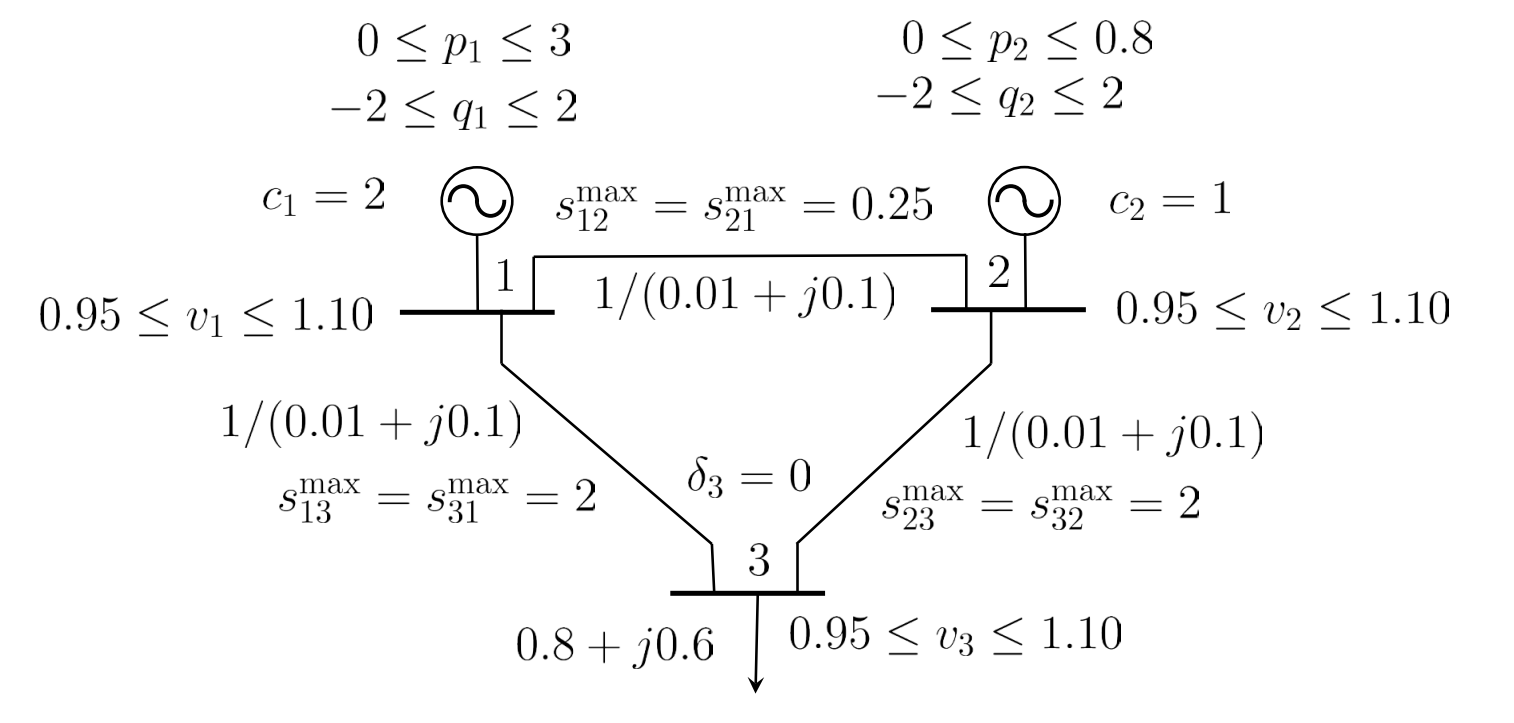

In [36]:
# =========================
# 3-bus Optimal Power Flow
# =========================

# Line data
z = 0.01 + 0.1im
y = 1 / z

# Bus admittance matrix
Y = [
    2y   -y   -y
    -y   2y   -y
    -y   -y   2y
]

G = real.(Y)
B = imag.(Y)

# Loads (only bus 3 has demand)
Pd = [0.0, 0.0, 0.8]
Qd = [0.0, 0.0, 0.6]

# Generation costs
c = [2.0, 1.0]

# Apparent power limits
Smax = Dict(
    (1, 2) => 0.25, (2, 1) => 0.25,
    (1, 3) => 2.0,  (3, 1) => 2.0,
    (2, 3) => 2.0,  (3, 2) => 2.0,
)

let
    model_opf = Model(Ipopt.Optimizer)
    set_silent(model_opf)

    # Variables
    @variable(model_opf, 0.95 <= v[1:3] <= 1.10)
    @variable(model_opf, δ[1:3])

    @variable(model_opf, 0.0 <= p1 <= 3.0)
    @variable(model_opf, -2.0 <= q1 <= 2.0)
    @variable(model_opf, 0.0 <= p2 <= 0.8)
    @variable(model_opf, -2.0 <= q2 <= 2.0)

    # Slack/reference bus
    fix(δ[3], 0.0; force=true)

    # Anonymous nonlinear expressions avoid name conflicts if the cell is rerun
    Pg = Vector{Any}(undef, 3)
    Qg = Vector{Any}(undef, 3)
    Pg[1] = @NLexpression(model_opf, p1)
    Qg[1] = @NLexpression(model_opf, q1)
    Pg[2] = @NLexpression(model_opf, p2)
    Qg[2] = @NLexpression(model_opf, q2)
    Pg[3] = @NLexpression(model_opf, 0.0)
    Qg[3] = @NLexpression(model_opf, 0.0)

    # Power balance at each bus
    for i in 1:3
        @NLconstraint(model_opf,
            Pg[i] - Pd[i] ==
            sum(v[i] * v[j] * (G[i, j] * cos(δ[i] - δ[j]) + B[i, j] * sin(δ[i] - δ[j])) for j in 1:3)
        )
        @NLconstraint(model_opf,
            Qg[i] - Qd[i] ==
            sum(v[i] * v[j] * (G[i, j] * sin(δ[i] - δ[j]) - B[i, j] * cos(δ[i] - δ[j])) for j in 1:3)
        )
    end

    # Branch flows
    P = Dict{Tuple{Int,Int},Any}()
    Q = Dict{Tuple{Int,Int},Any}()

    for (i, j) in [(1,2), (2,1), (1,3), (3,1), (2,3), (3,2)]
        gij = -real(Y[i, j])
        bij = -imag(Y[i, j])

        P[(i,j)] = @NLexpression(model_opf,
            v[i]^2 * gij - v[i] * v[j] * (gij * cos(δ[i] - δ[j]) + bij * sin(δ[i] - δ[j]))
        )
        Q[(i,j)] = @NLexpression(model_opf,
            -v[i]^2 * bij - v[i] * v[j] * (gij * sin(δ[i] - δ[j]) - bij * cos(δ[i] - δ[j]))
        )

        @NLconstraint(model_opf, P[(i,j)]^2 + Q[(i,j)]^2 <= Smax[(i,j)]^2)
    end

    # Objective
    @objective(model_opf, Min, c[1] * p1 + c[2] * p2)

    # Initial values
    set_start_value.(v, [1.0, 1.0, 1.0])
    set_start_value.(δ, [0.0, 0.0, 0.0])
    set_start_value(p1, 0.3)
    set_start_value(q1, 0.2)
    set_start_value(p2, 0.5)
    set_start_value(q2, 0.3)

    optimize!(model_opf)

    println("Status: ", termination_status(model_opf))
    println("Valor ótimo = ", objective_value(model_opf))
    println()

    println("p1 = ", value(p1))
    println("q1 = ", value(q1))
    println("p2 = ", value(p2))
    println("q2 = ", value(q2))
    println()

    println("v1 = ", value(v[1]))
    println("v2 = ", value(v[2]))
    println("v3 = ", value(v[3]))
    println()

    println("d1 = ", value(δ[1]))
    println("d2 = ", value(δ[2]))
    println("d3 = ", value(δ[3]))
    println()

    println("Fluxos:")
    println("P12 = ", value(P[(1,2)]), "   Q12 = ", value(Q[(1,2)]))
    println("P21 = ", value(P[(2,1)]), "   Q21 = ", value(Q[(2,1)]))
    println("P13 = ", value(P[(1,3)]), "   Q13 = ", value(Q[(1,3)]))
    println("P31 = ", value(P[(3,1)]), "   Q31 = ", value(Q[(3,1)]))
    println("P23 = ", value(P[(2,3)]), "   Q23 = ", value(Q[(2,3)]))
    println("P32 = ", value(P[(3,2)]), "   Q32 = ", value(Q[(3,2)]))
end

Status: LOCALLY_SOLVED
Valor ótimo = 0.8360786945615195

p1 = 0.030906834553260775
q1 = 0.32091669238596676
p2 = 0.774265025454998
q2 = 0.3308019076966262

v1 = 1.0977001927052608
v2 = 1.0999998938295106
v3 = 1.0663591316422725

d1 = 0.0212319668820324
d2 = 0.04191265995565188
d3 = 0.0

Fluxos:
P12 = -0.2494668952874448   Q12 = 0.002284894689777772
P21 = 0.24998342438840948   Q21 = 0.002880396319866918
P13 = 0.2803737298407266   Q13 = 0.31863179769615435
P31 = -0.27887876082316243   Q31 = -0.30368210752051006
P23 = 0.5242816010665577   Q23 = 0.32792151137690695
P32 = -0.5211212391768152   Q32 = -0.29631789247948603


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [38]:
X = [
    1.0  1.0  0.5  1.2
    1.0  2.0  1.0  2.1
    1.0  3.0  1.5  2.9
    1.0  4.0  2.0  3.8
    1.0  5.0  2.5  4.5
]

y = [2.0, 3.9, 6.1, 8.0, 9.8]

β = X \ y
ŷ = X * β
residuals = y - ŷ
sse = sum(residuals .^ 2)

println("Linear regression")
println("β = ", β)
println("predictions = ", ŷ)
println("SSE = ", sse)

Linear regression
β = [-0.28545454545453697, 1.0327272727272856, 0.5163636363636426, 0.8181818181817996]
predictions = [1.987272727272729, 4.0145454545454555, 5.960000000000003, 7.987272727272729, 9.850909090909095]
SSE = 0.03563636363636331


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [43]:
scores = [
    90 80 10 50
    60 70 50 65
    70 40 80 85
]

required = [70, 50, 85, 35]
hours_available = 80

n_designers, n_projects = size(scores)

model_alloc = Model(HiGHS.Optimizer)
set_silent(model_alloc)

@variable(model_alloc, H[1:n_designers, 1:n_projects] >= 0)

@objective(model_alloc, Max, sum(scores[i, j] * H[i, j] for i in 1:n_designers, j in 1:n_projects))

@constraint(model_alloc, [i in 1:n_designers], sum(H[i, j] for j in 1:n_projects) <= hours_available)
@constraint(model_alloc, [j in 1:n_projects], sum(H[i, j] for i in 1:n_designers) >= required[j])

optimize!(model_alloc)

println("Designer allocation")
println("Maximum score = ", objective_value(model_alloc))
for i in 1:n_designers
    println("Designer ", i, ": ", value.(H[i, :]))
end

Designer allocation
Maximum score = 18825.0
Designer 1: [70.0, 10.0, 0.0, 0.0]
Designer 2: [0.0, 40.0, 5.0, 35.0]
Designer 3: [0.0, 0.0, 80.0, 0.0]


# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [45]:
cost = [1.0, 0.5, 2.0, 0.3]
cal = [100.0, 200.0, 150.0, 70.0]
protein = [0.5, 4.0, 8.0, 6.0]
vitamins = [2.0, 0.0, 10.0, 0.0]

model_diet = Model(HiGHS.Optimizer)
set_silent(model_diet)

@variable(model_diet, y[1:4] >= 0)

@objective(model_diet, Min, sum(cost[i] * y[i] for i in 1:4))
@constraint(model_diet, sum(cal[i] * y[i] for i in 1:4) >= 500)
@constraint(model_diet, sum(protein[i] * y[i] for i in 1:4) >= 50)
@constraint(model_diet, sum(vitamins[i] * y[i] for i in 1:4) >= 100)

optimize!(model_diet)

foods = ["Apple", "Bread", "Milk", "Egg"]

println("Diet problem")
println("Minimum cost = ", objective_value(model_diet))
for i in 1:4
    println(foods[i], ": ", value(y[i]))
end

Diet problem
Minimum cost = 20.0
Apple: 0.0
Bread: 0.0
Milk: 10.0
Egg: 0.0


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [47]:
value_item = [120, 80, 60]
weight_item = [2.0, 1.0, 1.0]
capacity = 3.5

model_knapsack = Model(HiGHS.Optimizer)
set_silent(model_knapsack)

@variable(model_knapsack, x[1:3], Bin)

@objective(model_knapsack, Max, sum(value_item[i] * x[i] for i in 1:3))
@constraint(model_knapsack, sum(weight_item[i] * x[i] for i in 1:3) <= capacity)

optimize!(model_knapsack)

items = ["Tent", "Stove", "Food"]

println("Knapsack problem")
println("Maximum value = ", objective_value(model_knapsack))
for i in 1:3
    println(items[i], ": ", Int(round(value(x[i]))))
end

Knapsack problem
Maximum value = 200.0
Tent: 1
Stove: 1
Food: 0
